# Cross-Border Arbitrage Simulator

This notebook contains the main logic for the Cross-Border Arbitrage Simulator. It includes sections for importing libraries, fetching data, processing it, and visualizing results, all while using Shopify's ticker for demonstration purposes.

In [27]:
# 2) Cell 1: Imports and Global Parameters
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Parameters and fees
initial_capital = 10_000
cad_fee = 30              # flat CAD fee on CAD side
usd_fee_rate = 0.0003     # fee rate on USD side (converted to CAD)

# Company tickers
domestic_ticker = "SHOP.TO"   # TSX (CAD)
foreign_ticker = "SHOP"       # NYSE (USD)

# Time frame: 1 year ago → yesterday
end_date = datetime.today() - timedelta(days=1)
start_date = end_date - timedelta(days=365)

print(f"Date window: {start_date.date()} to {end_date.date()}")

Date window: 2025-03-16 to 2026-03-16


In [28]:
# 3) Cell 2: Ticker Metadata Fetch
domestic_info = yf.Ticker(domestic_ticker).info
foreign_info = yf.Ticker(foreign_ticker).info

name = domestic_info.get("longName", "N/A")
industry = domestic_info.get("industry", "N/A")
sector = domestic_info.get("sector", "N/A")
location = f"{domestic_info.get('city', '')}, {domestic_info.get('country', '')}"
domestic_exchange = domestic_info.get("exchange", "N/A")
foreign_exchange = foreign_info.get("exchange", "N/A")

company_df = pd.DataFrame([{
    "name": name,
    "domestic_ticker": domestic_ticker,
    "industry": industry,
    "sector": sector,
    "location": location,
    "domestic_exchange": domestic_exchange,
    "foreign_exchange": foreign_exchange,
    "foreign_ticker": foreign_ticker
}])

print("Company / Exchange Info:")
display(company_df)

Company / Exchange Info:


,name,domestic_ticker,industry,sector,location,domestic_exchange,foreign_exchange,foreign_ticker
0,Shopify Inc.,SHOP.TO,Software - Application,Technology,"Ottawa, Canada",TOR,NMS,SHOP


In [29]:
# 4) Cell 3: FX Rate Helper Function and Data Pull
def get_rate(ex_ticker, start_date, end_date):
    ex_rate = yf.Ticker(ex_ticker)
    ex_hist = ex_rate.history(start=start_date, end=end_date)
    ex_df = pd.DataFrame({"Exchange Rate": ex_hist["Close"]})
    ex_df.index = pd.to_datetime(ex_df.index.date)  # normalize to date only
    return ex_df

exchange_df = get_rate("CADUSD=X", start_date, end_date)  # USD per 1 CAD
exchange_df.head()

,Exchange Rate
2025-03-17,0.695933
2025-03-18,0.699540
2025-03-19,0.699325
2025-03-20,0.698373
2025-03-21,0.698192


In [30]:
# 5) Cell 4: Price Download, Cleanup, and Merge
prices = yf.download(
    [domestic_ticker, foreign_ticker],
    start=start_date,
    end=end_date,
    auto_adjust=True
)["Close"]

prices.index = pd.to_datetime(prices.index.date)

prices = prices.rename(columns={
    domestic_ticker: "Close_domestic",   # CAD
    foreign_ticker: "Close_foreign"      # USD
})

# Merge with FX
merged = prices.join(exchange_df, how="inner")
merged["Exchange Rate"] = merged["Exchange Rate"].ffill()

# Implied CAD price of US side
merged["CAD_implied_close_price"] = merged["Close_foreign"] / merged["Exchange Rate"]

merged_portfolio = merged[[
    "Close_domestic",
    "CAD_implied_close_price",
    "Close_foreign",
    "Exchange Rate"
]].dropna().copy()

print("Merged portfolio preview:")
display(merged_portfolio.head())

[*********************100%***********************]  2 of 2 completed

Merged portfolio preview:


,Close_domestic,CAD_implied_close_price,Close_foreign,Exchange Rate
2025-03-17,138.020004,138.792106,96.589996,0.695933
2025-03-18,134.380005,134.388243,94.010002,0.699540
2025-03-19,145.509995,145.197126,101.540001,0.699325
2025-03-20,145.699997,145.839015,101.849998,0.698373
2025-03-21,149.550003,149.256860,104.209999,0.698192


In [31]:
# 6) Cell 5: Arbitrage Strategy Function
def buy_sell_compounding(df, initial_capital, cad_fee, usd_fee_rate, min_rel_spread=0.0):
    capital = float(initial_capital)
    dates, capitals, trades = [], [], []

    df = df.dropna(subset=[
        "Close_domestic",
        "CAD_implied_close_price",
        "Close_foreign",
        "Exchange Rate"
    ])

    for d in df.index:
        actual = df.loc[d, "Close_domestic"]                # CAD
        implied = df.loc[d, "CAD_implied_close_price"]      # CAD
        implied_in_usd = df.loc[d, "Close_foreign"]         # USD
        cadusd = df.loc[d, "Exchange Rate"]                 # USD per CAD
        executed = 0

        if cadusd > 0:
            cad_per_usd = 1.0 / cadusd
            spread = abs(actual - implied)
            lower = min(actual, implied)

            # Relative spread filter
            if lower > 0 and (spread / lower) >= min_rel_spread:
                num_shares = int(np.floor(capital / lower))
                if num_shares > 0:
                    usd_notional = num_shares * implied_in_usd
                    usd_fee_cad = usd_notional * usd_fee_rate * cad_per_usd
                    fees_cad = cad_fee + usd_fee_cad

                    gross_edge_cad = spread * num_shares
                    if gross_edge_cad > fees_cad:
                        capital += gross_edge_cad - fees_cad
                        executed = 1

        dates.append(d)
        capitals.append(capital)
        trades.append(executed)

    equity_df = pd.DataFrame(
        {"Equity": capitals, "TradesExecuted": trades},
        index=pd.to_datetime(dates)
    )
    equity_df["Profit"] = equity_df["Equity"] - initial_capital
    return equity_df

In [32]:
# 7) Cell 6: Run Backtest + Performance Stats + Benchmarks
min_rel_spread = 0.001  # 10 bps

equity_df = buy_sell_compounding(
    merged_portfolio,
    initial_capital,
    cad_fee,
    usd_fee_rate,
    min_rel_spread=min_rel_spread
)

def perf_stats_from_curve(curve: pd.Series, initial_capital: float, ann: int = 252) -> pd.Series:
    r = curve.pct_change().dropna()
    n = len(r)

    years = max((curve.index[-1] - curve.index[0]).days / 365.25, 1 / 365.25)
    cagr = (curve.iloc[-1] / initial_capital) ** (1 / years) - 1
    vol = r.std() * np.sqrt(ann) if n > 1 else np.nan
    sharpe = (r.mean() * ann) / vol if (vol is not np.nan and vol and vol > 0) else np.nan
    dd = curve / curve.cummax() - 1
    mdd = dd.min()

    return pd.Series({
        "Final Equity": curve.iloc[-1],
        "Total Return": (curve.iloc[-1] / initial_capital) - 1,
        "CAGR": cagr,
        "Volatility": vol,
        "Sharpe": sharpe,
        "Max Drawdown": mdd
    })

# Benchmarks (same capital, buy-and-hold)
bench_df = pd.DataFrame(index=merged_portfolio.index)
bench_df["Strategy"] = equity_df["Equity"].reindex(bench_df.index).ffill()
bench_df["SHOP.TO Buy&Hold"] = initial_capital * (
    merged_portfolio["Close_domestic"] / merged_portfolio["Close_domestic"].iloc[0]
)
bench_df["SHOP (USD->CAD) Buy&Hold"] = initial_capital * (
    merged_portfolio["CAD_implied_close_price"] / merged_portfolio["CAD_implied_close_price"].iloc[0]
)
bench_df = bench_df.dropna()

# Stats table
stats_df = pd.DataFrame({
    col: perf_stats_from_curve(bench_df[col], initial_capital)
    for col in bench_df.columns
}).T

# Strategy-only execution metrics
win_rate = (equity_df["Equity"].diff() > 0).mean()
turnover = equity_df["TradesExecuted"].sum() / len(equity_df)

print(f"Backtest window: {equity_df.index.min().date()} → {equity_df.index.max().date()}")
print(f"Trades executed: {int(equity_df['TradesExecuted'].sum())}")
print(f"Win rate (days with positive PnL): {win_rate:.2%}")
print(f"Turnover (trades/day): {turnover:.4f}")

display(stats_df.style.format({
    "Final Equity": "{:,.2f}",
    "Total Return": "{:.2%}",
    "CAGR": "{:.2%}",
    "Volatility": "{:.2%}",
    "Sharpe": "{:.2f}",
    "Max Drawdown": "{:.2%}"
}))

Backtest window: 2025-03-17 → 2026-03-16
Trades executed: 79
Win rate (days with positive PnL): 31.84%
Turnover (trades/day): 0.3224


,Final Equity,Total Return,CAGR,Volatility,Sharpe,Max Drawdown
Strategy,"11,747.82",17.48%,17.54%,2.25%,7.29,0.00%
SHOP.TO Buy&Hold,"12,549.63",25.50%,25.59%,62.21%,0.68,-39.71%
SHOP (USD->CAD) Buy&Hold,"12,505.23",25.05%,25.15%,62.55%,0.68,-40.00%


In [33]:
# 10) Cell 9: Per-Trade Log
def build_trade_log(df, initial_capital, cad_fee, usd_fee_rate, min_rel_spread=0.0):
    capital = float(initial_capital)
    records = []

    df = df.dropna(subset=[
        "Close_domestic",
        "CAD_implied_close_price",
        "Close_foreign",
        "Exchange Rate"
    ])

    for d in df.index:
        actual   = df.loc[d, "Close_domestic"]
        implied  = df.loc[d, "CAD_implied_close_price"]
        usd_price = df.loc[d, "Close_foreign"]
        cadusd   = df.loc[d, "Exchange Rate"]

        if cadusd <= 0:
            continue

        cad_per_usd = 1.0 / cadusd
        spread      = abs(actual - implied)
        lower       = min(actual, implied)

        if lower > 0 and (spread / lower) >= min_rel_spread:
            num_shares   = int(np.floor(capital / lower))
            if num_shares > 0:
                usd_notional  = num_shares * usd_price
                usd_fee_cad   = usd_notional * usd_fee_rate * cad_per_usd
                fees_cad      = cad_fee + usd_fee_cad
                gross_edge    = spread * num_shares
                net_profit    = gross_edge - fees_cad

                if net_profit > 0:
                    direction = "Buy TSX / Sell NYSE" if actual < implied else "Buy NYSE / Sell TSX"
                    capital  += net_profit
                    records.append({
                        "Date":              d,
                        "Direction":         direction,
                        "TSX Price (CAD)":   round(actual, 4),
                        "NYSE Implied (CAD)": round(implied, 4),
                        "Spread %":          round(spread / lower * 100, 4),
                        "Shares":            num_shares,
                        "Gross Edge (CAD)":  round(gross_edge, 2),
                        "Fees (CAD)":        round(fees_cad, 2),
                        "Net Profit (CAD)":  round(net_profit, 2),
                        "Capital After":     round(capital, 2),
                    })

    return pd.DataFrame(records).set_index("Date") if records else pd.DataFrame()

trade_log = build_trade_log(
    merged_portfolio, initial_capital, cad_fee, usd_fee_rate, min_rel_spread=min_rel_spread
)

print(f"Total trades logged: {len(trade_log)}")
print(f"Total net profit:    CAD {trade_log['Net Profit (CAD)'].sum():,.2f}")
print(f"Avg net profit/trade: CAD {trade_log['Net Profit (CAD)'].mean():,.2f}")
print(f"Avg spread %:         {trade_log['Spread %'].mean():.4f}%\n")
display(trade_log)

Total trades logged: 79
Total net profit:    CAD 1,747.80
Avg net profit/trade: CAD 22.12
Avg spread %:         0.5136%



,Direction,TSX Price (CAD),NYSE Implied (CAD),Spread %,Shares,Gross Edge (CAD),Fees (CAD),Net Profit (CAD),Capital After
Date,,,,,,,,,
2025-03-17,Buy TSX / Sell NYSE,138.02,138.7921,0.5594,72,55.59,33.00,22.59,10022.59
2025-04-01,Buy TSX / Sell NYSE,139.72,140.5108,0.5660,71,56.15,32.99,23.15,10045.75
2025-04-03,Buy TSX / Sell NYSE,115.88,116.9876,0.9558,86,95.25,33.02,62.23,10107.98
2025-04-04,Buy NYSE / Sell TSX,109.42,108.2688,1.0633,93,107.06,33.02,74.04,10182.02
2025-04-09,Buy TSX / Sell NYSE,129.09,130.2724,0.9160,78,92.23,33.05,59.18,10241.20
...,...,...,...,...,...,...,...,...,...
2026-02-18,Buy NYSE / Sell TSX,166.57,165.8890,0.4105,70,47.67,33.48,14.19,11642.51
2026-02-23,Buy NYSE / Sell TSX,160.67,160.0696,0.3751,72,43.23,33.46,9.77,11652.29
2026-03-04,Buy TSX / Sell NYSE,176.75,177.2847,0.3025,65,34.75,33.46,1.30,11653.58


## Spread Distribution Analysis

The two charts below examine the statistical structure of the daily price gap between SHOP.TO (TSX, in CAD) and SHOP (NYSE, converted to CAD via the live FX rate).

**Left — Spread % Histogram:** Shows how often different spread sizes occur over the backtest window. A right-skewed distribution (long tail to the right) indicates that large mispricings are rare but significant. The mean and median lines reveal whether typical spreads are wide enough to survive fees.

**Right — Rolling 30-Day Spread Over Time:** Tracks how the average spread has evolved month-by-month. Periods where the rolling mean rises sharply often correspond to FX volatility or market stress — exactly when the most arbitrage profit is available. The shaded ±1 std dev band shows how consistent or erratic the spread is within each rolling window.

**Top-10 Table:** Surfaces the specific dates where the mispricing was largest, allowing you to cross-reference with macro events (earnings, rate decisions, tariff news) that may have driven the dislocation.

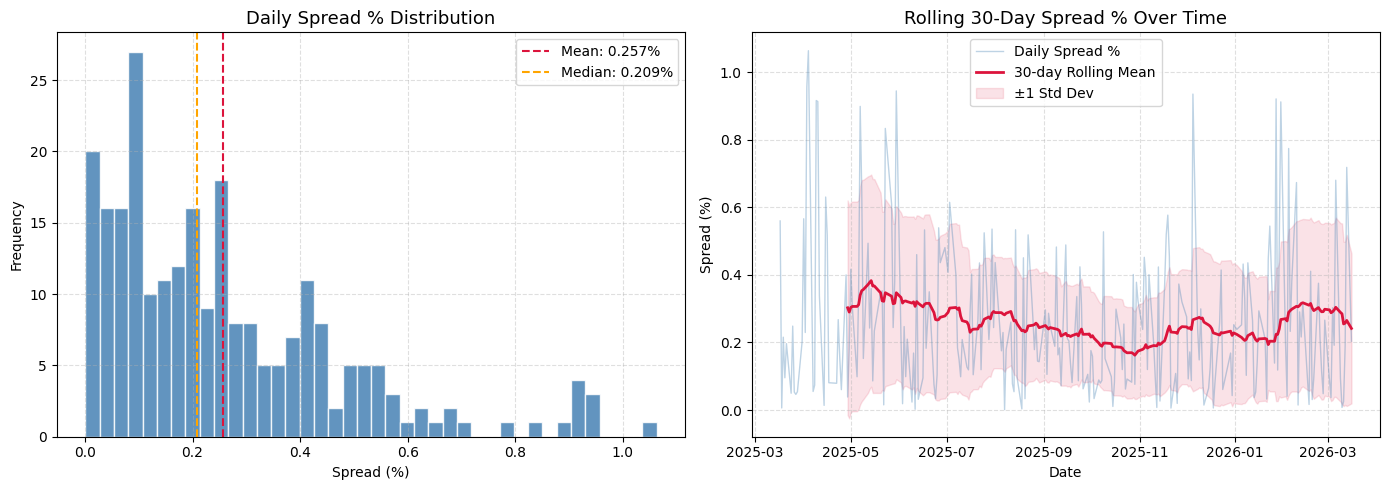

Top-10 Highest-Spread Days:


,TSX Price (CAD),NYSE Implied (CAD),CADUSD Rate,Spread (CAD),Spread %
2025-04-04 00:00:00,109.4200,108.2688,0.710177,1.1512,1.0633%
2025-04-03 00:00:00,115.8800,116.9876,0.703408,1.1076,0.9558%
2025-05-30 00:00:00,146.6400,148.0247,0.724338,1.3847,0.9443%
2025-12-05 00:00:00,222.7800,224.8629,0.716348,2.0829,0.9349%
2026-01-27 00:00:00,186.8200,188.5400,0.729288,1.7200,0.9207%
2025-04-09 00:00:00,129.0900,130.2724,0.701607,1.1824,0.9160%
2025-04-10 00:00:00,118.2600,119.3393,0.709154,1.0793,0.9126%
2026-01-30 00:00:00,178.6700,177.0555,0.741180,1.6145,0.9119%
2025-05-07 00:00:00,131.2900,130.1208,0.726248,1.1692,0.8985%
2025-05-23 00:00:00,139.5100,140.6726,0.721605,1.1626,0.8333%


In [34]:
# 11) Cell 10: Spread Distribution Analysis
spread_df = merged_portfolio.copy()
spread_df["Spread_CAD"]  = (spread_df["Close_domestic"] - spread_df["CAD_implied_close_price"]).abs()
spread_df["Spread_Pct"]  = spread_df["Spread_CAD"] / spread_df[["Close_domestic", "CAD_implied_close_price"]].min(axis=1) * 100
spread_df["Roll30_Mean"] = spread_df["Spread_Pct"].rolling(30).mean()
spread_df["Roll30_Std"]  = spread_df["Spread_Pct"].rolling(30).std()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Left: histogram of daily spread %
axes[0].hist(spread_df["Spread_Pct"].dropna(), bins=40, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(spread_df["Spread_Pct"].mean(), color="crimson", linewidth=1.5, linestyle="--", label=f"Mean: {spread_df['Spread_Pct'].mean():.3f}%")
axes[0].axvline(spread_df["Spread_Pct"].median(), color="orange", linewidth=1.5, linestyle="--", label=f"Median: {spread_df['Spread_Pct'].median():.3f}%")
axes[0].set_title("Daily Spread % Distribution", fontsize=13)
axes[0].set_xlabel("Spread (%)")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.4)

# -- Right: rolling 30-day mean spread over time with ±1σ band
axes[1].plot(spread_df.index, spread_df["Spread_Pct"], color="steelblue", alpha=0.35, linewidth=1, label="Daily Spread %")
axes[1].plot(spread_df.index, spread_df["Roll30_Mean"], color="crimson", linewidth=2, label="30-day Rolling Mean")
axes[1].fill_between(
    spread_df.index,
    spread_df["Roll30_Mean"] - spread_df["Roll30_Std"],
    spread_df["Roll30_Mean"] + spread_df["Roll30_Std"],
    color="crimson", alpha=0.12, label="±1 Std Dev"
)
axes[1].set_title("Rolling 30-Day Spread % Over Time", fontsize=13)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Spread (%)")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# -- Top-10 highest-spread days
top10 = (
    spread_df[["Close_domestic", "CAD_implied_close_price", "Exchange Rate", "Spread_CAD", "Spread_Pct"]]
    .nlargest(10, "Spread_Pct")
    .rename(columns={
        "Close_domestic":          "TSX Price (CAD)",
        "CAD_implied_close_price": "NYSE Implied (CAD)",
        "Exchange Rate":           "CADUSD Rate",
        "Spread_CAD":              "Spread (CAD)",
        "Spread_Pct":              "Spread %",
    })
)

print("Top-10 Highest-Spread Days:")
display(top10.style.format({
    "TSX Price (CAD)":    "{:.4f}",
    "NYSE Implied (CAD)": "{:.4f}",
    "CADUSD Rate":        "{:.6f}",
    "Spread (CAD)":       "{:.4f}",
    "Spread %":           "{:.4f}%",
}))

## Monthly P&L Breakdown

The chart and table below aggregate every trade from the trade log into calendar months, revealing the seasonality and consistency of the strategy.

**Bar Chart:** Net profit per month in CAD. Months where the strategy earns nothing appear as zero — these are periods where no mispricing survived fees, or where the FX rate kept the two prices too close together. Tall bars often cluster around earnings releases or macro FX moves.

**Summary Table:** For each month, shows total net profit, number of trades taken, total fees paid, average spread % on traded days, and the profit-to-fee ratio. A ratio below 1.0 would mean fees consumed more than the gross edge — a red flag for that period.

Together these help identify which market regimes are most favourable for cross-border arbitrage and whether performance is driven by a handful of outlier months or is broadly consistent.

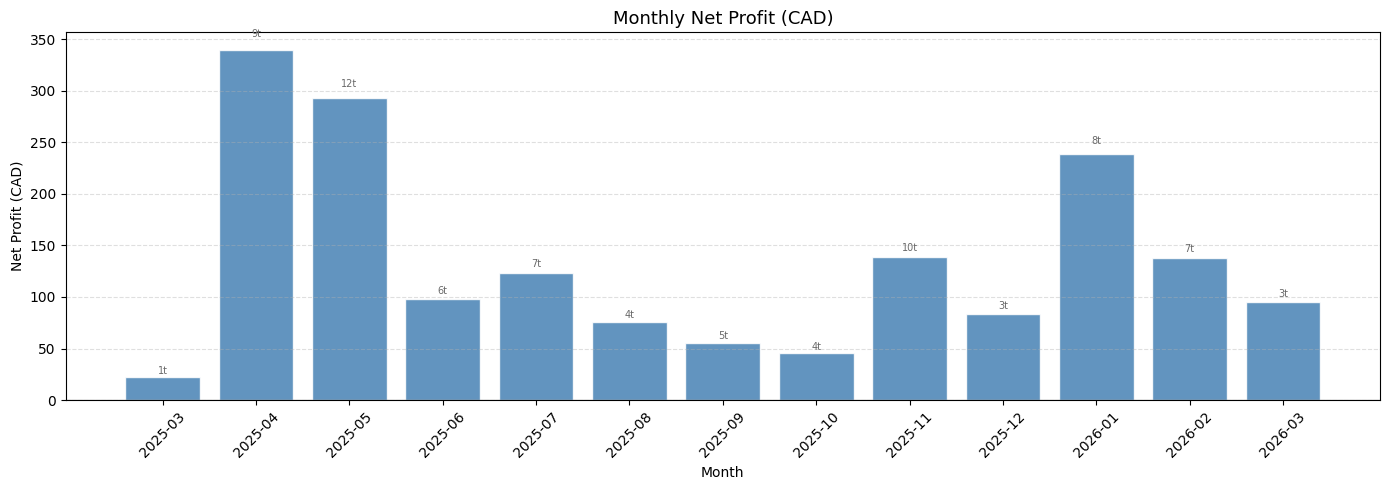

Best month:  2025-04  →  CAD 339.75
Worst month: 2025-03 →  CAD 22.59
Profitable months: 13 / 13



,Net Profit (CAD),Trades,Fees (CAD),Avg Spread %,Profit / Fee Ratio
Month,,,,,
2025-03,CAD 22.59,1,CAD 33.00,0.5594%,0.68x
2025-04,CAD 339.75,9,CAD 297.53,0.6999%,1.14x
2025-05,CAD 292.86,12,CAD 397.57,0.5524%,0.74x
2025-06,CAD 98.20,6,CAD 199.18,0.4665%,0.49x
2025-07,CAD 123.33,7,CAD 232.55,0.4742%,0.53x
2025-08,CAD 75.82,4,CAD 132.95,0.4847%,0.57x
2025-09,CAD 55.71,5,CAD 166.32,0.4085%,0.33x
2025-10,CAD 45.22,4,CAD 133.15,0.4073%,0.34x
2025-11,CAD 138.61,10,CAD 333.10,0.4283%,0.42x


In [35]:
# 12) Cell 11: Monthly P&L Breakdown
if trade_log.empty:
    print("No trades in log — run the trade log cell first.")
else:
    monthly = trade_log.copy()
    monthly.index = pd.to_datetime(monthly.index)
    monthly["Month"] = monthly.index.to_period("M")

    monthly_summary = monthly.groupby("Month").agg(
        Net_Profit   = ("Net Profit (CAD)", "sum"),
        Trades       = ("Net Profit (CAD)", "count"),
        Total_Fees   = ("Fees (CAD)",        "sum"),
        Avg_Spread   = ("Spread %",          "mean"),
    ).reset_index()

    monthly_summary["Profit_to_Fee"] = (
        monthly_summary["Net_Profit"] / monthly_summary["Total_Fees"].replace(0, float("nan"))
    ).round(2)

    # -- Bar chart
    fig, ax = plt.subplots(figsize=(14, 5))
    colors = ["steelblue" if v >= 0 else "crimson" for v in monthly_summary["Net_Profit"]]
    bars = ax.bar(
        monthly_summary["Month"].astype(str),
        monthly_summary["Net_Profit"],
        color=colors, edgecolor="white", alpha=0.85
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title("Monthly Net Profit (CAD)", fontsize=13)
    ax.set_xlabel("Month")
    ax.set_ylabel("Net Profit (CAD)")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)

    # annotate trade count above each bar
    for bar, n in zip(bars, monthly_summary["Trades"]):
        height = bar.get_height()
        offset = max(abs(height) * 0.03, 1)
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + (offset if height >= 0 else -offset * 3),
            f"{n}t", ha="center", va="bottom", fontsize=7, color="dimgray"
        )

    plt.tight_layout()
    plt.show()

    # -- Summary table
    display_summary = monthly_summary.rename(columns={
        "Month":          "Month",
        "Net_Profit":     "Net Profit (CAD)",
        "Trades":         "Trades",
        "Total_Fees":     "Fees (CAD)",
        "Avg_Spread":     "Avg Spread %",
        "Profit_to_Fee":  "Profit / Fee Ratio",
    }).set_index("Month")

    best  = display_summary["Net Profit (CAD)"].idxmax()
    worst = display_summary["Net Profit (CAD)"].idxmin()
    print(f"Best month:  {best}  →  CAD {display_summary.loc[best,  'Net Profit (CAD)']:,.2f}")
    print(f"Worst month: {worst} →  CAD {display_summary.loc[worst, 'Net Profit (CAD)']:,.2f}")
    print(f"Profitable months: {(display_summary['Net Profit (CAD)'] > 0).sum()} / {len(display_summary)}\n")

    display(display_summary.style.format({
        "Net Profit (CAD)":   "CAD {:,.2f}",
        "Fees (CAD)":         "CAD {:,.2f}",
        "Avg Spread %":       "{:.4f}%",
        "Profit / Fee Ratio": "{:.2f}x",
    }).background_gradient(subset=["Net Profit (CAD)"], cmap="RdYlGn"))

## Drawdown Analysis

Drawdown measures how far the strategy's equity has fallen from its most recent peak at any point in time. It answers the question: *how much pain would you have endured while running this strategy?*

**Drawdown Chart:** The shaded area shows the percentage decline from the rolling equity peak on each day. A flat line at 0% means the strategy is at an all-time high. Deep troughs represent extended periods where no profitable trades occurred and capital stagnated below a previous peak. Because this strategy only earns on mispricing days, drawdowns are caused by fee drag on marginal trades or long gaps between opportunities — not by losing trades in the traditional sense.

**Underwater Period Table:** Lists every distinct drawdown episode — when it started, when it recovered, how deep it went, and how many calendar days it lasted. Long shallow drawdowns suggest the strategy grinds slowly through low-spread regimes. Short deep ones suggest a cluster of fee-heavy marginal trades.

**Key stats** (max drawdown %, longest drawdown duration, average recovery time) give a quick read on the worst-case experience an investor would have faced.

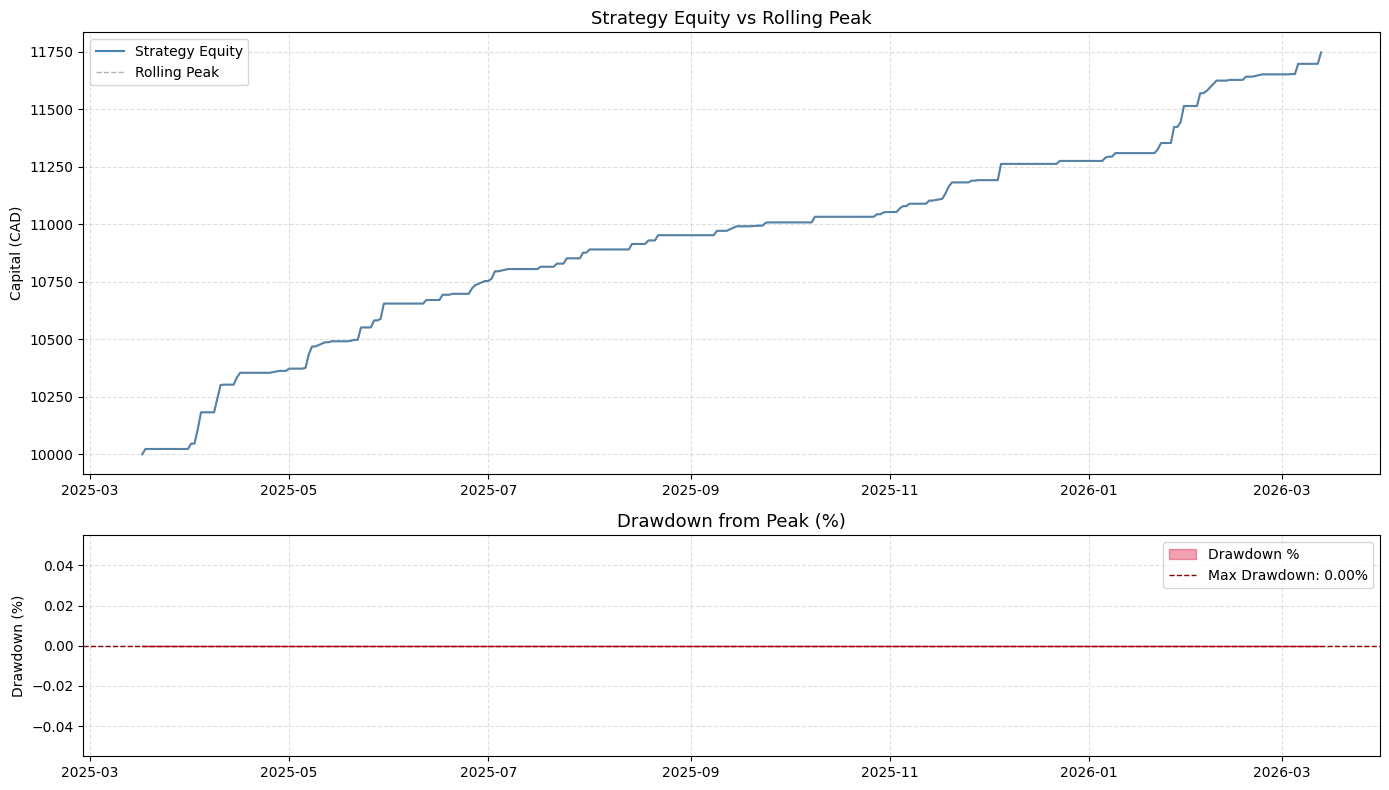

Max drawdown:          0.00%  (on 2025-03-17)
Total drawdown episodes: 0


In [36]:
# 13) Cell 12: Drawdown Analysis
if trade_log.empty:
    print("No trades in log — run the trade log cell first.")
else:
    # Build a daily equity series by forward-filling "Capital After" across all trading days
    equity_series = pd.Series(
        trade_log["Capital After"].values,
        index=pd.to_datetime(trade_log.index)
    )
    all_days = pd.date_range(equity_series.index.min(), equity_series.index.max(), freq="B")
    equity_daily = equity_series.reindex(all_days).ffill().fillna(initial_capital)
    equity_daily.iloc[0] = initial_capital  # anchor start

    # Rolling peak and drawdown
    rolling_peak  = equity_daily.cummax()
    drawdown_pct  = (equity_daily - rolling_peak) / rolling_peak * 100  # always <= 0

    max_dd        = drawdown_pct.min()
    max_dd_date   = drawdown_pct.idxmin()

    # -- Drawdown chart
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [2, 1]})

    axes[0].plot(equity_daily.index, equity_daily, color="steelblue", linewidth=1.5, label="Strategy Equity")
    axes[0].plot(rolling_peak.index, rolling_peak, color="gray", linewidth=1, linestyle="--", alpha=0.6, label="Rolling Peak")
    axes[0].set_title("Strategy Equity vs Rolling Peak", fontsize=13)
    axes[0].set_ylabel("Capital (CAD)")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.4)

    axes[1].fill_between(drawdown_pct.index, drawdown_pct, 0, color="crimson", alpha=0.4, label="Drawdown %")
    axes[1].plot(drawdown_pct.index, drawdown_pct, color="crimson", linewidth=0.8)
    axes[1].axhline(max_dd, color="darkred", linewidth=1, linestyle="--",
                    label=f"Max Drawdown: {max_dd:.2f}%")
    axes[1].set_title("Drawdown from Peak (%)", fontsize=13)
    axes[1].set_ylabel("Drawdown (%)")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

    # -- Identify drawdown episodes
    in_dd     = drawdown_pct < 0
    episodes  = []
    start     = None

    for date, val in drawdown_pct.items():
        if val < 0 and start is None:
            start = date
            trough_val  = val
            trough_date = date
        elif val < 0 and start is not None:
            if val < trough_val:
                trough_val  = val
                trough_date = date
        elif val == 0 and start is not None:
            episodes.append({
                "Start":          start,
                "Trough Date":    trough_date,
                "Recovery Date":  date,
                "Max Drawdown %": round(trough_val, 4),
                "Duration (days)": (date - start).days,
            })
            start = None

    # close any open episode at end of series
    if start is not None:
        episodes.append({
            "Start":           start,
            "Trough Date":     trough_date,
            "Recovery Date":   None,
            "Max Drawdown %":  round(trough_val, 4),
            "Duration (days)": (equity_daily.index[-1] - start).days,
        })

    dd_table = pd.DataFrame(episodes)

    print(f"Max drawdown:          {max_dd:.2f}%  (on {max_dd_date.date()})")
    print(f"Total drawdown episodes: {len(dd_table)}")
    if not dd_table.empty:
        print(f"Longest episode:       {dd_table['Duration (days)'].max()} days")
        recovered = dd_table[dd_table["Recovery Date"].notna()]
        if not recovered.empty:
            print(f"Avg recovery time:     {recovered['Duration (days)'].mean():.0f} days\n")
        display(dd_table.sort_values("Max Drawdown %").reset_index(drop=True).style.format({
            "Max Drawdown %":  "{:.4f}%",
            "Duration (days)": "{:,}",
        }))

## FX Sensitivity Analysis

Because the arbitrage edge is derived by converting NYSE prices into CAD, the CADUSD exchange rate sits at the heart of every trade. This section stress-tests the strategy by artificially shifting the historical FX rate up or down and re-running the full backtest under each scenario.

**Sensitivity Bar Chart:** Shows total net profit (CAD) for each FX rate shift from −15% to +15% in 5% increments. A steep slope means the strategy is highly FX-dependent — small moves in the exchange rate dramatically change how often a mispricing appears and how large it is. A flat slope means the strategy is robust across rate regimes.

**Scenario Table:** For each FX shift, reports total net profit, number of trades taken, total fees paid, and average spread %. Comparing trade count across scenarios reveals whether a stronger or weaker CAD creates more or fewer opportunities rather than just larger or smaller ones.

**Why it matters:** Real-world CADUSD can move 10–15% over a year. If the strategy only works in a narrow FX band, that is a significant unhedged risk. A scenario where profit flips negative under a plausible FX move is a red flag worth knowing before deploying capital.

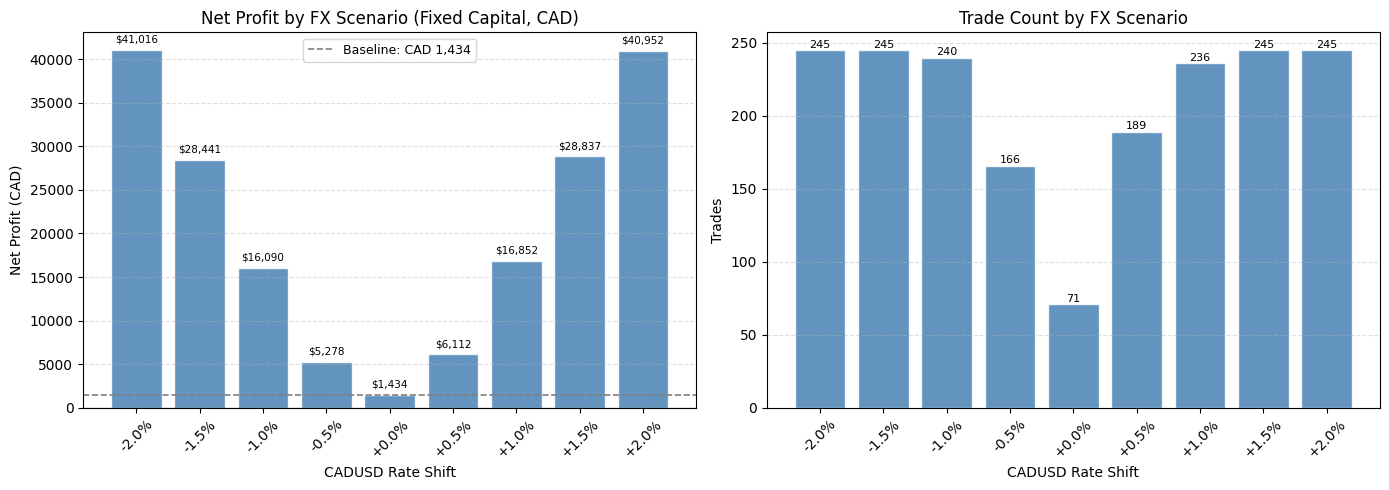

,Net Profit (CAD),Trades,Fees (CAD),Avg Spread %
FX Shift,,,,
-2.0%,"CAD 41,016.40",245,"CAD 8,093.46",2.0220%
-1.5%,"CAD 28,441.00",245,"CAD 8,089.61",1.5041%
-1.0%,"CAD 16,090.32",240,"CAD 7,921.09",1.0093%
-0.5%,"CAD 5,278.36",166,"CAD 5,476.67",0.6538%
+0.0%,"CAD 1,433.67",71,"CAD 2,341.80",0.5363%
+0.5%,"CAD 6,112.21",189,"CAD 6,231.73",0.6593%
+1.0%,"CAD 16,851.73",236,"CAD 7,781.57",1.0535%
+1.5%,"CAD 28,836.79",245,"CAD 8,078.63",1.5199%
+2.0%,"CAD 40,951.60",245,"CAD 8,078.25",2.0200%


In [37]:
# 14) Cell 13: FX Sensitivity Analysis
def build_trade_log_fixed_capital(df, capital, cad_fee, usd_fee_rate, min_rel_spread=0.0):
    """Non-compounding version: uses the same fixed capital for every trade."""
    records = []
    df = df.dropna(subset=["Close_domestic", "CAD_implied_close_price", "Close_foreign", "Exchange Rate"])

    for d in df.index:
        actual    = df.loc[d, "Close_domestic"]
        implied   = df.loc[d, "CAD_implied_close_price"]
        usd_price = df.loc[d, "Close_foreign"]
        cadusd    = df.loc[d, "Exchange Rate"]
        if cadusd <= 0:
            continue

        cad_per_usd = 1.0 / cadusd
        spread      = abs(actual - implied)
        lower       = min(actual, implied)

        if lower > 0 and (spread / lower) >= min_rel_spread:
            num_shares  = int(np.floor(capital / lower))
            if num_shares > 0:
                usd_notional = num_shares * usd_price
                fees_cad     = cad_fee + usd_notional * usd_fee_rate * cad_per_usd
                gross_edge   = spread * num_shares
                net_profit   = gross_edge - fees_cad
                if net_profit > 0:
                    records.append({
                        "Date":             d,
                        "Spread %":         round(spread / lower * 100, 4),
                        "Shares":           num_shares,
                        "Fees (CAD)":       round(fees_cad, 2),
                        "Net Profit (CAD)": round(net_profit, 2),
                    })

    return pd.DataFrame(records).set_index("Date") if records else pd.DataFrame()

# Realistic daily FX stress range: CADUSD moves ~0.5-2% on a typical day
fx_shifts  = [-0.020, -0.015, -0.010, -0.005, 0.0, 0.005, 0.010, 0.015, 0.020]
fx_results = []

for shift in fx_shifts:
    scenario_df = merged_portfolio.copy()
    scenario_df["Exchange Rate"]           = scenario_df["Exchange Rate"] * (1 + shift)
    scenario_df["CAD_implied_close_price"] = scenario_df["Close_foreign"] / scenario_df["Exchange Rate"]

    log = build_trade_log_fixed_capital(
        scenario_df, initial_capital, cad_fee, usd_fee_rate, min_rel_spread=min_rel_spread
    )

    fx_results.append({
        "FX Shift":         f"{shift:+.1%}",
        "Net Profit (CAD)": round(log["Net Profit (CAD)"].sum(), 2) if not log.empty else 0.0,
        "Trades":           len(log),
        "Fees (CAD)":       round(log["Fees (CAD)"].sum(), 2)       if not log.empty else 0.0,
        "Avg Spread %":     round(log["Spread %"].mean(), 4)         if not log.empty else 0.0,
    })

fx_df = pd.DataFrame(fx_results)

# -- Charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_colors = ["steelblue" if v >= 0 else "crimson" for v in fx_df["Net Profit (CAD)"]]
bars = axes[0].bar(fx_df["FX Shift"], fx_df["Net Profit (CAD)"], color=bar_colors, edgecolor="white", alpha=0.85)
axes[0].axhline(0, color="black", linewidth=0.8)

baseline_val = fx_df.loc[fx_df["FX Shift"] == "+0.0%", "Net Profit (CAD)"].values
if len(baseline_val):
    axes[0].axhline(baseline_val[0], color="gray", linewidth=1.2, linestyle="--",
                    label=f"Baseline: CAD {baseline_val[0]:,.0f}")
    axes[0].legend(fontsize=9)

for bar, val in zip(bars, fx_df["Net Profit (CAD)"]):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(abs(fx_df["Net Profit (CAD)"].max()) * 0.015, 2),
        f"${val:,.0f}", ha="center", va="bottom", fontsize=7.5
    )

axes[0].set_title("Net Profit by FX Scenario (Fixed Capital, CAD)", fontsize=12)
axes[0].set_xlabel("CADUSD Rate Shift")
axes[0].set_ylabel("Net Profit (CAD)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, axis="y", linestyle="--", alpha=0.4)

axes[1].bar(fx_df["FX Shift"], fx_df["Trades"], color="steelblue", edgecolor="white", alpha=0.85)
for bar, n in zip(axes[1].patches, fx_df["Trades"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 str(n), ha="center", va="bottom", fontsize=8)
axes[1].set_title("Trade Count by FX Scenario", fontsize=12)
axes[1].set_xlabel("CADUSD Rate Shift")
axes[1].set_ylabel("Trades")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True, axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

display(fx_df.set_index("FX Shift").style.format({
    "Net Profit (CAD)": "CAD {:,.2f}",
    "Fees (CAD)":       "CAD {:,.2f}",
    "Avg Spread %":     "{:.4f}%",
}).background_gradient(subset=["Net Profit (CAD)"], cmap="RdYlGn"))

## Fee Break-Even Analysis

Every trade must generate enough gross edge to cover two costs: a flat CAD commission and a percentage-based USD commission. This section asks: *how large does the spread need to be before a trade is worth taking?*

**Break-Even Spread Curve:** For each flat CAD fee level, the minimum spread percentage required to cover total fees at the current capital level. Overlaid on the actual spread distribution (median, mean, 25th and 75th percentiles), this shows your margin of safety — the gap between what the market typically offers and what you need to break even. A narrow gap means one bad fee day wipes the edge; a wide gap means the strategy is robust to fee increases.

**Gross Edge vs Fees Scatter:** Each dot is one trade from the trade log. The x-axis is fees paid, the y-axis is gross edge earned. The diagonal line is break-even — dots above it are profitable, dots below it are losses. Clustering near the line reveals how many trades are marginal and would flip unprofitable with a small fee increase.

**Fee Sensitivity Table:** Runs the full backtest at several flat fee levels and shows the resulting profit, trade count, and average margin of safety (actual spread minus break-even spread). This directly answers: what fee level kills the strategy?

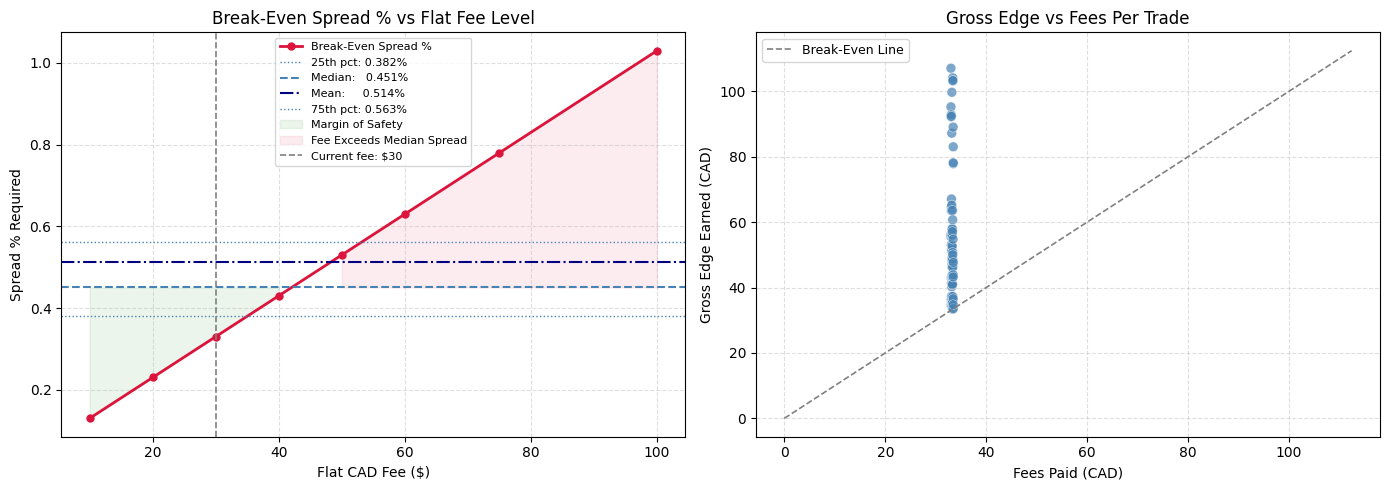

Current fee ($30) break-even spread: 0.3300%
Actual median spread on traded days:        0.4505%



,Net Profit (CAD),Trades,Break-Even Spread %,Avg Margin of Safety
CAD Fee ($),,,,
10,"CAD 3,653.73",156,0.1300%,+0.2373%
20,"CAD 2,304.67",112,0.2300%,+0.2095%
30,"CAD 1,433.67",71,0.3300%,+0.2063%
40,CAD 847.67,45,0.4300%,+0.1935%
50,CAD 509.37,25,0.5300%,+0.2096%
60,CAD 322.91,15,0.6300%,+0.2221%
75,CAD 141.70,10,0.7800%,+0.1491%
100,CAD 2.92,1,1.0300%,+0.0333%


In [38]:
# 15) Cell 14: Fee Break-Even Analysis
if trade_log.empty:
    print("No trades in log — run the trade log cell first.")
else:
    fee_levels = [10, 20, 30, 40, 50, 60, 75, 100]

    # Break-even spread % = (cad_fee + capital * usd_fee_rate) / capital * 100
    # (approximation: usd_price / cad_price * cad_per_usd ≈ 1)
    breakeven_pct = [(f + initial_capital * usd_fee_rate) / initial_capital * 100
                     for f in fee_levels]

    # Actual spread distribution from trade log
    actual_spreads = trade_log["Spread %"]
    p25  = actual_spreads.quantile(0.25)
    med  = actual_spreads.median()
    mean = actual_spreads.mean()
    p75  = actual_spreads.quantile(0.75)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # -- Left: break-even curve vs actual spread distribution
    axes[0].plot(fee_levels, breakeven_pct, color="crimson", linewidth=2,
                 marker="o", markersize=5, label="Break-Even Spread %")
    axes[0].axhline(p25,  color="steelblue", linewidth=1,   linestyle=":",  label=f"25th pct: {p25:.3f}%")
    axes[0].axhline(med,  color="steelblue", linewidth=1.5, linestyle="--", label=f"Median:   {med:.3f}%")
    axes[0].axhline(mean, color="navy",      linewidth=1.5, linestyle="-.", label=f"Mean:     {mean:.3f}%")
    axes[0].axhline(p75,  color="steelblue", linewidth=1,   linestyle=":",  label=f"75th pct: {p75:.3f}%")
    axes[0].fill_between(fee_levels, breakeven_pct, med,
                         where=[b < med for b in breakeven_pct],
                         color="green", alpha=0.08, label="Margin of Safety")
    axes[0].fill_between(fee_levels, breakeven_pct, med,
                         where=[b >= med for b in breakeven_pct],
                         color="crimson", alpha=0.08, label="Fee Exceeds Median Spread")
    axes[0].axvline(cad_fee, color="gray", linewidth=1.2, linestyle="--",
                    label=f"Current fee: ${cad_fee}")
    axes[0].set_title("Break-Even Spread % vs Flat Fee Level", fontsize=12)
    axes[0].set_xlabel("Flat CAD Fee ($)")
    axes[0].set_ylabel("Spread % Required")
    axes[0].legend(fontsize=8)
    axes[0].grid(True, linestyle="--", alpha=0.4)

    # -- Right: gross edge vs fees scatter per trade
    gross = trade_log["Gross Edge (CAD)"]
    fees  = trade_log["Fees (CAD)"]
    margin = gross - fees
    colors_scatter = ["steelblue" if m > 0 else "crimson" for m in margin]
    axes[1].scatter(fees, gross, c=colors_scatter, alpha=0.7, edgecolors="white", linewidths=0.4, s=50)
    max_val = max(gross.max(), fees.max()) * 1.05
    axes[1].plot([0, max_val], [0, max_val], color="gray", linewidth=1.2,
                 linestyle="--", label="Break-Even Line")
    axes[1].set_title("Gross Edge vs Fees Per Trade", fontsize=12)
    axes[1].set_xlabel("Fees Paid (CAD)")
    axes[1].set_ylabel("Gross Edge Earned (CAD)")
    axes[1].legend(fontsize=9)
    axes[1].grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

    # -- Fee sensitivity table
    fee_rows = []
    for f in fee_levels:
        log_f = build_trade_log_fixed_capital(
            merged_portfolio, initial_capital, f, usd_fee_rate, min_rel_spread=min_rel_spread
        )
        be = (f + initial_capital * usd_fee_rate) / initial_capital * 100
        safety = round(log_f["Spread %"].mean() - be, 4) if not log_f.empty else float("nan")
        fee_rows.append({
            "CAD Fee ($)":          f,
            "Net Profit (CAD)":     round(log_f["Net Profit (CAD)"].sum(), 2) if not log_f.empty else 0.0,
            "Trades":               len(log_f),
            "Break-Even Spread %":  round(be, 4),
            "Avg Margin of Safety": safety,
        })

    fee_df = pd.DataFrame(fee_rows).set_index("CAD Fee ($)")
    print(f"Current fee (${cad_fee}) break-even spread: "
          f"{(cad_fee + initial_capital * usd_fee_rate) / initial_capital * 100:.4f}%")
    print(f"Actual median spread on traded days:        {med:.4f}%\n")
    display(fee_df.style.format({
        "Net Profit (CAD)":     "CAD {:,.2f}",
        "Break-Even Spread %":  "{:.4f}%",
        "Avg Margin of Safety": "{:+.4f}%",
    }).background_gradient(subset=["Net Profit (CAD)"], cmap="RdYlGn"))

## Multi-Ticker Comparison

The analysis so far has focused exclusively on Shopify (SHOP.TO / SHOP). This section runs the same arbitrage strategy across a basket of other large-cap Canadian companies that are dual-listed on both the TSX and NYSE, using the same capital, fee structure, and spread threshold.

**Why compare tickers?** Not all dual-listed stocks are equally mispriced. Some trade with tighter bid-ask spreads, higher liquidity, or more FX sensitivity than others. By running the strategy on multiple names simultaneously, this section identifies which stocks offer the most consistent arbitrage opportunities — and which are too efficiently priced for the strategy to work.

**Net Profit Bar Chart:** Total profit per ticker under fixed capital. A taller bar means more cumulative edge was available over the backtest window. Differences can stem from higher spread volatility, more trading days with qualifying mispricings, or simply a higher stock price giving more edge per share.

**Summary Table:** For each ticker, shows net profit, number of profitable trades, average spread %, and average profit per trade. Sorting by average profit per trade (rather than total) helps compare tickers that may have had very different numbers of qualifying days.

In [ ]:
# 16) Cell 15: Multi-Ticker Comparison
def run_ticker_backtest(tsx_ticker, nyse_ticker, fx_df, start, end, capital, cad_fee, usd_fee_rate, min_spread):
    """Download, merge, and backtest a single TSX/NYSE pair. Returns summary dict."""
    try:
        raw = yf.download([tsx_ticker, nyse_ticker], start=start, end=end, auto_adjust=True, progress=False)
        if raw.empty:
            return None

        close = raw["Close"][[tsx_ticker, nyse_ticker]].dropna()
        close.columns = ["Close_domestic", "Close_foreign"]
        close.index = pd.to_datetime(close.index).tz_localize(None)

        merged = close.join(fx_df.rename("Exchange Rate"), how="inner").dropna()
        merged["CAD_implied_close_price"] = merged["Close_foreign"] / merged["Exchange Rate"]

        log = build_trade_log_fixed_capital(merged, capital, cad_fee, usd_fee_rate, min_rel_spread=min_spread)

        if log.empty:
            return {"Ticker Pair": f"{tsx_ticker} / {nyse_ticker}", "Net Profit (CAD)": 0.0,
                    "Trades": 0, "Avg Spread %": 0.0, "Avg Profit/Trade (CAD)": 0.0, "Total Fees (CAD)": 0.0}

        return {
            "Ticker Pair":           f"{tsx_ticker} / {nyse_ticker}",
            "Net Profit (CAD)":      round(log["Net Profit (CAD)"].sum(), 2),
            "Trades":                len(log),
            "Avg Spread %":          round(log["Spread %"].mean(), 4),
            "Avg Profit/Trade (CAD)":round(log["Net Profit (CAD)"].mean(), 2),
            "Total Fees (CAD)":      round(log["Fees (CAD)"].sum(), 2),
        }
    except Exception as e:
        print(f"  Skipping {tsx_ticker}/{nyse_ticker}: {e}")
        return None

# Dual-listed TSX/NYSE pairs to scan
ticker_pairs = [
    ("SHOP.TO", "SHOP"),   # Shopify (baseline)
    ("RY.TO",   "RY"),     # Royal Bank of Canada
    ("TD.TO",   "TD"),     # TD Bank
    ("ENB.TO",  "ENB"),    # Enbridge
    ("CNQ.TO",  "CNQ"),    # Canadian Natural Resources
    ("CP.TO",   "CP"),     # Canadian Pacific Kansas City
    ("MFC.TO",  "MFC"),    # Manulife Financial
    ("SU.TO",   "SU"),     # Suncor Energy
]

# Reuse the FX series already downloaded
fx_series = merged_portfolio["Exchange Rate"].dropna()

print("Running multi-ticker backtest...")
multi_results = []
for tsx, nyse in ticker_pairs:
    print(f"  {tsx} / {nyse} ...", end=" ")
    result = run_ticker_backtest(
        tsx, nyse, fx_series,
        start=merged_portfolio.index.min(),
        end=merged_portfolio.index.max(),
        capital=initial_capital,
        cad_fee=cad_fee,
        usd_fee_rate=usd_fee_rate,
        min_spread=min_rel_spread,
    )
    if result:
        multi_results.append(result)
        print(f"CAD {result['Net Profit (CAD)']:,.2f}  ({result['Trades']} trades)")
    else:
        print("no data")

multi_df = pd.DataFrame(multi_results).set_index("Ticker Pair")
multi_df_sorted = multi_df.sort_values("Net Profit (CAD)", ascending=False)

# -- Bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_colors = ["gold" if "SHOP" in t else "steelblue" for t in multi_df_sorted.index]
bars = axes[0].bar(multi_df_sorted.index, multi_df_sorted["Net Profit (CAD)"],
                   color=bar_colors, edgecolor="white", alpha=0.85)
for bar, val in zip(bars, multi_df_sorted["Net Profit (CAD)"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + multi_df_sorted["Net Profit (CAD)"].max() * 0.01,
                 f"${val:,.0f}", ha="center", va="bottom", fontsize=8)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Net Profit by Ticker (Fixed Capital, CAD)", fontsize=12)
axes[0].set_ylabel("Net Profit (CAD)")
axes[0].tick_params(axis="x", rotation=30)
axes[0].grid(True, axis="y", linestyle="--", alpha=0.4)

bar_colors2 = ["gold" if "SHOP" in t else "steelblue" for t in multi_df_sorted.index]
bars2 = axes[1].bar(multi_df_sorted.index, multi_df_sorted["Avg Profit/Trade (CAD)"],
                    color=bar_colors2, edgecolor="white", alpha=0.85)
for bar, val in zip(bars2, multi_df_sorted["Avg Profit/Trade (CAD)"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + multi_df_sorted["Avg Profit/Trade (CAD)"].max() * 0.01,
                 f"${val:,.1f}", ha="center", va="bottom", fontsize=8)
axes[1].set_title("Avg Profit Per Trade by Ticker (CAD)", fontsize=12)
axes[1].set_ylabel("Avg Profit / Trade (CAD)")
axes[1].tick_params(axis="x", rotation=30)
axes[1].grid(True, axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# -- Summary table
display(multi_df_sorted.style.format({
    "Net Profit (CAD)":       "CAD {:,.2f}",
    "Avg Spread %":           "{:.4f}%",
    "Avg Profit/Trade (CAD)": "CAD {:,.2f}",
    "Total Fees (CAD)":       "CAD {:,.2f}",
}).background_gradient(subset=["Net Profit (CAD)"], cmap="RdYlGn"))

## Export / Reporting

This cell saves the full backtest output to two files in the `outputs/` folder alongside this notebook:

- **`arb_report.xlsx`** — a multi-sheet Excel workbook, one tab per analysis section, formatted and ready to share
- **`trade_log.csv`** — the raw per-trade log as a flat CSV, useful for further analysis in Excel or other tools

**Sheets in the workbook:**
- `Summary` — key performance stats (total profit, trade count, Sharpe-like ratio, max drawdown, best/worst month)
- `Trade Log` — every individual trade with date, direction, prices, spread, shares, gross edge, fees, and net profit
- `Monthly P&L` — aggregated monthly breakdown with trade count, fees, avg spread, and profit-to-fee ratio
- `Spread Distribution` — daily spread data (TSX price, implied price, spread CAD, spread %) across the full backtest window
- `Multi-Ticker` — cross-ticker comparison results if the multi-ticker cell was run

Running this cell at the end of a session snapshots the current state of all results cleanly, without needing to re-run the notebook.

In [ ]:
# 17) Cell 16: Export / Reporting
import os
from datetime import datetime

output_dir = os.path.join(os.path.dirname(os.path.abspath("__file__")), "outputs")
os.makedirs(output_dir, exist_ok=True)

run_date   = datetime.today().strftime("%Y-%m-%d")
xlsx_path  = os.path.join(output_dir, f"arb_report_{run_date}.xlsx")
csv_path   = os.path.join(output_dir, f"trade_log_{run_date}.csv")

# ── 1. Build summary stats ────────────────────────────────────────────────────
summary_rows = [
    ("Run Date",             run_date),
    ("Ticker (TSX)",         domestic_ticker),
    ("Ticker (NYSE)",        foreign_ticker),
    ("Backtest Start",       str(merged_portfolio.index.min().date())),
    ("Backtest End",         str(merged_portfolio.index.max().date())),
    ("Initial Capital (CAD)", initial_capital),
    ("Flat CAD Fee ($)",     cad_fee),
    ("USD Fee Rate",         usd_fee_rate),
    ("Min Rel Spread",       min_rel_spread),
]

if not trade_log.empty:
    total_profit  = trade_log["Net Profit (CAD)"].sum()
    total_trades  = len(trade_log)
    avg_profit    = trade_log["Net Profit (CAD)"].mean()
    avg_spread    = trade_log["Spread %"].mean()
    total_fees    = trade_log["Fees (CAD)"].sum()

    # Drawdown from equity series
    eq = pd.Series(trade_log["Capital After"].values, index=pd.to_datetime(trade_log.index))
    all_days = pd.date_range(eq.index.min(), eq.index.max(), freq="B")
    eq_daily = eq.reindex(all_days).ffill().fillna(initial_capital)
    peak     = eq_daily.cummax()
    dd_pct   = (eq_daily - peak) / peak * 100
    max_dd   = dd_pct.min()

    # Monthly best/worst
    monthly_net = trade_log.copy()
    monthly_net.index = pd.to_datetime(monthly_net.index)
    monthly_net = monthly_net["Net Profit (CAD)"].resample("ME").sum()
    best_month  = monthly_net.idxmax()
    worst_month = monthly_net.idxmin()

    summary_rows += [
        ("─── Performance ───",   ""),
        ("Total Net Profit (CAD)", round(total_profit, 2)),
        ("Total Trades",           total_trades),
        ("Avg Profit / Trade (CAD)", round(avg_profit, 2)),
        ("Total Fees Paid (CAD)",  round(total_fees, 2)),
        ("Avg Spread % (traded days)", round(avg_spread, 4)),
        ("Max Drawdown %",         round(max_dd, 4)),
        ("Best Month",             str(best_month.date()) if best_month else "N/A"),
        ("Best Month Profit (CAD)",round(monthly_net.max(), 2)),
        ("Worst Month",            str(worst_month.date()) if worst_month else "N/A"),
        ("Worst Month Profit (CAD)", round(monthly_net.min(), 2)),
    ]

summary_df = pd.DataFrame(summary_rows, columns=["Metric", "Value"])

# ── 2. Monthly P&L ────────────────────────────────────────────────────────────
if not trade_log.empty:
    ml = trade_log.copy()
    ml.index = pd.to_datetime(ml.index)
    ml["Month"] = ml.index.to_period("M")
    monthly_export = ml.groupby("Month").agg(
        Net_Profit=("Net Profit (CAD)", "sum"),
        Trades=("Net Profit (CAD)", "count"),
        Fees=("Fees (CAD)", "sum"),
        Avg_Spread=("Spread %", "mean"),
    )
    monthly_export["Profit_to_Fee"] = (monthly_export["Net_Profit"] / monthly_export["Fees"].replace(0, float("nan"))).round(2)
    monthly_export.index = monthly_export.index.astype(str)
else:
    monthly_export = pd.DataFrame()

# ── 3. Spread distribution ────────────────────────────────────────────────────
spread_export = spread_df[["Close_domestic", "CAD_implied_close_price", "Exchange Rate", "Spread_CAD", "Spread_Pct"]].copy()
spread_export.index = spread_export.index.strftime("%Y-%m-%d")

# ── 4. Multi-ticker (if available) ───────────────────────────────────────────
multi_export = multi_df_sorted.copy() if "multi_df_sorted" in dir() and not multi_df_sorted.empty else pd.DataFrame()

# ── 5. Write Excel workbook ───────────────────────────────────────────────────
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    summary_df.to_excel(writer, sheet_name="Summary", index=False)

    if not trade_log.empty:
        tl = trade_log.copy()
        tl.index = pd.to_datetime(tl.index).strftime("%Y-%m-%d")
        tl.to_excel(writer, sheet_name="Trade Log")

    if not monthly_export.empty:
        monthly_export.to_excel(writer, sheet_name="Monthly P&L")

    spread_export.to_excel(writer, sheet_name="Spread Distribution")

    if not multi_export.empty:
        multi_export.to_excel(writer, sheet_name="Multi-Ticker")

    # Auto-fit column widths
    for sheet_name, ws in writer.sheets.items():
        for col in ws.columns:
            max_len = max((len(str(cell.value)) for cell in col if cell.value), default=8)
            ws.column_dimensions[col[0].column_letter].width = min(max_len + 2, 40)

# ── 6. Write CSV ──────────────────────────────────────────────────────────────
if not trade_log.empty:
    trade_log.to_csv(csv_path)

print(f"Saved Excel report: {xlsx_path}")
print(f"Saved trade log CSV: {csv_path}")
print(f"\nSheets written:")
print(f"  • Summary             — {len(summary_df)} rows")
print(f"  • Trade Log           — {len(trade_log)} trades")
print(f"  • Monthly P&L         — {len(monthly_export)} months")
print(f"  • Spread Distribution — {len(spread_export)} days")
if not multi_export.empty:
    print(f"  • Multi-Ticker        — {len(multi_export)} tickers")

## Equity Curve Comparison

The chart below plots the growth of $10,000 CAD over the backtest window across three scenarios run on the same data.

**Strategy:** The arbitrage simulator's compounding equity — capital grows only on days where a profitable mispricing is detected and the gross edge exceeds total fees. Flat periods represent days with no qualifying trade.

**SHOP.TO Buy & Hold:** A passive benchmark that simply holds the TSX-listed shares from day one. This reflects what a Canadian investor would have earned without any active trading.

**SHOP (USD→CAD) Buy & Hold:** The same passive benchmark using the NYSE price converted to CAD each day. Divergence between this line and the TSX benchmark reveals the FX drag (or tailwind) embedded in holding the US-listed shares.

Comparing the strategy line against both benchmarks shows whether the arbitrage alpha is genuine or whether a simple buy-and-hold would have outperformed.

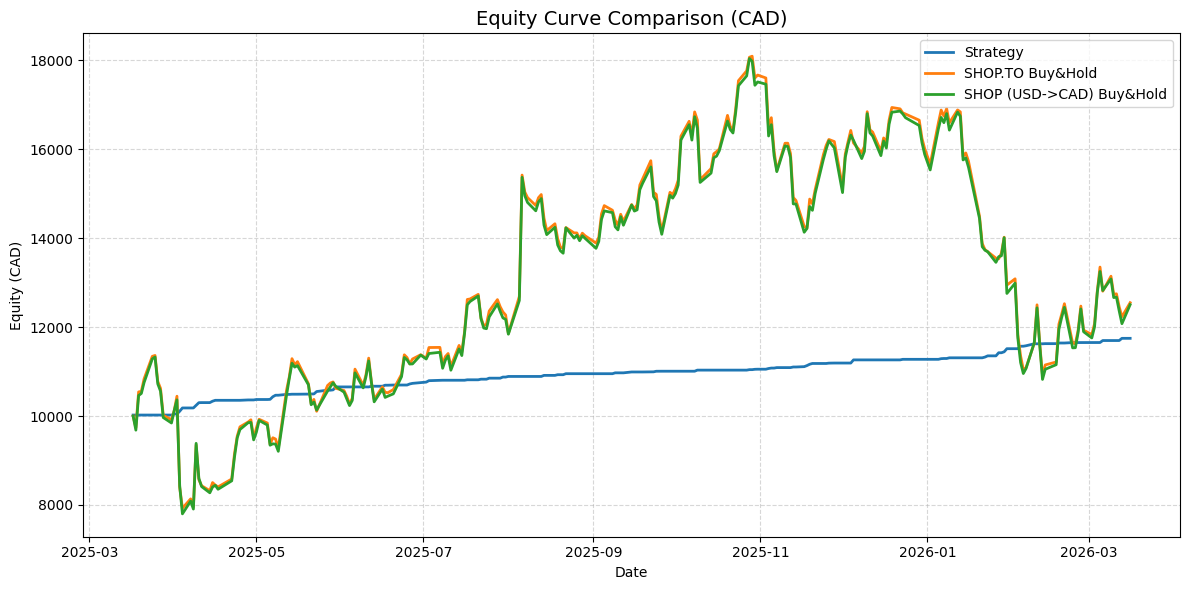

In [39]:
# 8) Cell 7: Plot Equity Curves (Strategy vs Benchmarks)
plt.figure(figsize=(12, 6))
for col in bench_df.columns:
    plt.plot(bench_df.index, bench_df[col], linewidth=2, label=col)

plt.title("Equity Curve Comparison (CAD)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Equity (CAD)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [40]:
# 9) Cell 8: Optional Parameter Sweep (fees/spread threshold)
spread_grid = [0.0000, 0.0005, 0.0010, 0.0020, 0.0030]
cad_fee_grid = [20, 30, 40]

results = []
for s in spread_grid:
    for fee in cad_fee_grid:
        eq = buy_sell_compounding(
            merged_portfolio,
            initial_capital=initial_capital,
            cad_fee=fee,
            usd_fee_rate=usd_fee_rate,
            min_rel_spread=s
        )
        results.append({
            "min_rel_spread": s,
            "cad_fee": fee,
            "final_equity": eq["Equity"].iloc[-1],
            "total_profit": eq["Profit"].iloc[-1],
            "trades_executed": int(eq["TradesExecuted"].sum())
        })

sensitivity_df = pd.DataFrame(results).sort_values(
    by=["total_profit", "trades_executed"],
    ascending=[False, False]
)

display(sensitivity_df)

,min_rel_spread,cad_fee,final_equity,total_profit,trades_executed
0,0.0000,20,12968.992290,2968.992290,122
3,0.0005,20,12968.992290,2968.992290,122
6,0.0010,20,12968.992290,2968.992290,122
9,0.0020,20,12967.041418,2967.041418,119
12,0.0030,20,12685.696284,2685.696284,78
1,0.0000,30,11747.823392,1747.823392,79
4,0.0005,30,11747.823392,1747.823392,79
7,0.0010,30,11747.823392,1747.823392,79
10,0.0020,30,11747.823392,1747.823392,79
13,0.0030,30,11747.715819,1747.715819,77
